# ROUGE from Scratch — A Runnable Tutorial

**ROUGE** (Recall-Oriented Understudy for Gisting Evaluation) measures how much of a human **reference** is *recovered* by a machine-generated text. Where BLEU asks *"how much of what the candidate said is correct?"* (precision), ROUGE asks *"how much of the reference did the candidate cover?"* (recall). Invented for **summarization**, it's the standard companion to BLEU.



**Contents**
1. Tokenization & n-grams
2. ROUGE-N recall (and why "recall")
3. Precision, recall, and the F-measure (the `beta` knob)
4. ROUGE-L: longest common subsequence
5. Why LCS? Order without requiring contiguity
6. Putting it all together — the full `rouge_l()`
7. The real `sum-rain` case: ROUGE vs. BLEU on the same answer
8. ROUGE's biases, visualized
9. (Optional) cross-check vs. a reference implementation

No third-party libraries are required for sections 1–8 — only the Python standard library. `matplotlib` is used for the plots in section 8.

## 1. Tokenization & n-grams

Like BLEU, ROUGE works on **tokens**, not raw characters. We lowercase and split on word characters — the same simple tokenizer as `evals/metrics.py`. (Production tools like `rouge-score` offer optional stemming and stopword removal; for learning, simple is clearer.)

An **n-gram** is a window of `n` consecutive tokens. ROUGE-N counts shared n-grams; ROUGE-L (later) counts a shared *subsequence*.

In [8]:
import re
from collections import Counter

def tokens(text):
    """Lowercase and split into word tokens."""
    return re.findall(r"\w+", text.lower())

def ngrams(toks, n):
    """Count of each n-gram (as tuples) in a token list."""
    return Counter(tuple(toks[i:i + n]) for i in range(len(toks) - n + 1))

s = "The cat sat on the mat"
print("tokens: ", tokens(s))
print("1-grams:", dict(ngrams(tokens(s), 1)))
print("2-grams:", dict(ngrams(tokens(s), 2)))

tokens:  ['the', 'cat', 'sat', 'on', 'the', 'mat']
1-grams: {('the',): 2, ('cat',): 1, ('sat',): 1, ('on',): 1, ('mat',): 1}
2-grams: {('the', 'cat'): 1, ('cat', 'sat'): 1, ('sat', 'on'): 1, ('on', 'the'): 1, ('the', 'mat'): 1}


Note `('the',)` has a count of **2** — "the" occurs at positions 0 and 4. As with BLEU, repetition is counted but will be *clipped* against the reference in the next step.

## 2. ROUGE-N recall

**ROUGE-N recall** = *of the n-grams in the reference, how many did the candidate reproduce?*

$$ \text{recall}_N = \frac{\sum_{g}\min\big(\text{count}_\text{cand}(g),\ \text{count}_\text{ref}(g)\big)}{\sum_{g}\text{count}_\text{ref}(g)} $$

The denominator is the **reference** length (in n-grams) — that's what makes ROUGE recall-oriented. BLEU's modified precision uses the **candidate** length instead. The numerator is the same *clipped overlap* BLEU uses: each n-gram counts at most as many times as it appears in the reference.

In [9]:
def rouge_n_recall(candidate, reference, n):
    """Clipped n-gram recall for a single order n."""
    cand_counts = ngrams(tokens(candidate), n)
    print(cand_counts)
    ref_counts = ngrams(tokens(reference), n)
    print(ref_counts)

    overlap = sum(min(c, cand_counts[g]) for g, c in ref_counts.items())
    total = sum(ref_counts.values())          # reference n-gram count
    return overlap, total, (overlap / total if total else 0.0)

ref = "the cat sat on the mat"

# A candidate that covers most of the reference
for n in (1, 2):
    o, t, r = rouge_n_recall("the cat sat on the mat today", ref, n)
    print(f"ROUGE-{n} recall = {o}/{t} = {r:.2f}   (candidate longer, still recovers reference)")

print()
# A short candidate: high precision but LOW recall — the mirror image of BLEU's blind spot
for n in (1, 2):
    o, t, r = rouge_n_recall("the cat", ref, n)
    print(f"ROUGE-{n} recall = {o}/{t} = {r:.2f}   ('the cat' misses most of the reference)")

Counter({('the',): 2, ('cat',): 1, ('sat',): 1, ('on',): 1, ('mat',): 1, ('today',): 1})
Counter({('the',): 2, ('cat',): 1, ('sat',): 1, ('on',): 1, ('mat',): 1})
ROUGE-1 recall = 6/6 = 1.00   (candidate longer, still recovers reference)
Counter({('the', 'cat'): 1, ('cat', 'sat'): 1, ('sat', 'on'): 1, ('on', 'the'): 1, ('the', 'mat'): 1, ('mat', 'today'): 1})
Counter({('the', 'cat'): 1, ('cat', 'sat'): 1, ('sat', 'on'): 1, ('on', 'the'): 1, ('the', 'mat'): 1})
ROUGE-2 recall = 5/5 = 1.00   (candidate longer, still recovers reference)

Counter({('the',): 1, ('cat',): 1})
Counter({('the',): 2, ('cat',): 1, ('sat',): 1, ('on',): 1, ('mat',): 1})
ROUGE-1 recall = 2/6 = 0.33   ('the cat' misses most of the reference)
Counter({('the', 'cat'): 1})
Counter({('the', 'cat'): 1, ('cat', 'sat'): 1, ('sat', 'on'): 1, ('on', 'the'): 1, ('the', 'mat'): 1})
ROUGE-2 recall = 1/5 = 0.20   ('the cat' misses most of the reference)


`"the cat"` would score high **precision** under BLEU (everything it says is right) but low **ROUGE recall** (it covers little of the reference). That complementarity is exactly why the harness reports both.

## 3. Precision, recall, and the F-measure

Recall alone is gameable in the opposite direction from precision: dump the entire dictionary and you'll "cover" every reference word. So full ROUGE combines **both**:

- **recall** = clipped overlap / reference length  *(did we cover the reference?)*
- **precision** = clipped overlap / candidate length  *(is what we said on-target?)*

They're combined with an **F-measure**, weighted by `beta` (how many times more you value recall than precision):

$$ F_\beta = \frac{(1+\beta^2)\,\cdot\,\text{prec}\,\cdot\,\text{rec}}{\text{rec} + \beta^2\,\cdot\,\text{prec}} $$

`beta = 1` is the familiar balanced F1. ROUGE conventionally uses **`beta = 1.2`**, tilting slightly toward recall — and that's the value this repo's `rouge_l()` uses.

In [10]:
def f_measure(prec, rec, beta=1.2):
    if prec == 0 or rec == 0:
        return 0.0
    return ((1 + beta ** 2) * prec * rec) / (rec + beta ** 2 * prec)

# Show how beta shifts the balance for a recall-heavy / precision-light case
prec, rec = 0.9, 0.3
for beta in (0.5, 1.0, 1.2, 2.0):
    tilt = "recall" if beta > 1 else ("precision" if beta < 1 else "balanced")
    print(f"beta={beta:<4} F={f_measure(prec, rec, beta):.3f}   (favors {tilt})")

print(f"\nprecision={prec}, recall={rec} — higher beta pulls F toward the lower recall value")

beta=0.5  F=0.643   (favors precision)
beta=1.0  F=0.450   (favors balanced)
beta=1.2  F=0.413   (favors recall)
beta=2.0  F=0.346   (favors recall)

precision=0.9, recall=0.3 — higher beta pulls F toward the lower recall value


## 4. ROUGE-L: longest common subsequence

ROUGE-N requires n-grams to match *contiguously*. **ROUGE-L** relaxes this: it credits the **longest common subsequence (LCS)** — the longest run of words appearing in **both** texts in the **same order**, but *not necessarily adjacent*.

Example:
```
reference:  the cat sat on the mat
candidate:  the cat quickly sat on a mat
LCS:        the cat        sat on   mat     -> length 5
```
The inserted word `quickly` and the swap `the -> a` break the n-grams, but the LCS still threads through the shared, correctly-ordered words. LCS rewards **word order and coverage without demanding exact adjacency** — a better fit for summaries, which legitimately reorder and insert.

In [11]:
def lcs_len(a, b):
    """Length of the longest common subsequence (classic DP, O(len(a)*len(b)))."""
    dp = [0] * (len(b) + 1)
    for x in a:
        prev = 0
        for j, y in enumerate(b, 1):
            prev, dp[j] = dp[j], (prev + 1 if x == y else max(dp[j], dp[j - 1]))
    return dp[-1]

ref = "the cat sat on the mat"
cand = "the cat quickly sat on a mat"
L = lcs_len(tokens(cand), tokens(ref))
print(f"tokens(cand) = {tokens(cand)}")
print(f"tokens(ref)  = {tokens(ref)}")
print(f"LCS length   = {L}")

# Contrast with ROUGE-2, which the inserted word breaks
o, t, r2 = rouge_n_recall(cand, ref, 2)
print(f"\nROUGE-2 recall = {o}/{t} = {r2:.2f}  (bigrams broken by 'quickly' / 'a')")
print(f"LCS-based recall = {L}/{len(tokens(ref))} = {L/len(tokens(ref)):.2f}  (LCS survives insertions)")

tokens(cand) = ['the', 'cat', 'quickly', 'sat', 'on', 'a', 'mat']
tokens(ref)  = ['the', 'cat', 'sat', 'on', 'the', 'mat']
LCS length   = 5
Counter({('the', 'cat'): 1, ('cat', 'quickly'): 1, ('quickly', 'sat'): 1, ('sat', 'on'): 1, ('on', 'a'): 1, ('a', 'mat'): 1})
Counter({('the', 'cat'): 1, ('cat', 'sat'): 1, ('sat', 'on'): 1, ('on', 'the'): 1, ('the', 'mat'): 1})

ROUGE-2 recall = 2/5 = 0.40  (bigrams broken by 'quickly' / 'a')
LCS-based recall = 5/6 = 0.83  (LCS survives insertions)


## 5. Why LCS? Order without requiring contiguity

The subsequence is the sweet spot between two extremes:

- **Bag of words** (order-blind): "mat the on sat cat the" would score perfectly — clearly wrong.
- **Exact n-gram match** (order-strict + adjacency-strict): a single inserted word shatters long n-grams, punishing legitimate paraphrase.

LCS keeps **order** (a subsequence must preserve sequence) but drops the **adjacency** requirement. So it credits a summary that says the right things in the right order, even if it adds connective words or drops a few.

In [12]:
ref = "the cat sat on the mat"
examples = {
    "identical":        "the cat sat on the mat",
    "inserted words":   "the cat then sat on the mat",
    "dropped words":    "cat sat mat",
    "reordered (bad)":  "mat the on sat cat the",
    "unrelated":        "quantum physics is hard",
}
print(f"{'candidate':20} LCS  recall")
for label, cand in examples.items():
    L = lcs_len(tokens(cand), tokens(ref))
    rec = L / len(tokens(ref))
    print(f"{label:20} {L:>3}  {rec:.2f}")

print("\nNote 'reordered (bad)' scores lower than 'identical' despite the same words — order matters.")

candidate            LCS  recall
identical              6  1.00
inserted words         6  1.00
dropped words          3  0.50
reordered (bad)        3  0.50
unrelated              0  0.00

Note 'reordered (bad)' scores lower than 'identical' despite the same words — order matters.


## 6. Putting it all together — the full `rouge_l()`

ROUGE-L F-measure combines LCS-based precision and recall through the `beta`-weighted F-measure:

$$ \text{prec} = \frac{\text{LCS}}{|\text{candidate}|}, \qquad \text{rec} = \frac{\text{LCS}}{|\text{reference}|}, \qquad \text{ROUGE-L} = F_\beta(\text{prec}, \text{rec}) $$

This is a from-scratch re-implementation of `evals/metrics.py::rouge_l` — same tokenizer, same LCS, same `beta = 1.2`.

In [19]:
def rouge_l(candidate, reference, beta=1.2):
    """ROUGE-L F-measure based on longest common subsequence."""
    cand, ref = tokens(candidate), tokens(reference)
    if not cand or not ref:
        return 0.0
    lcs = lcs_len(cand, ref)
    if lcs == 0:
        return 0.0
    prec = lcs / len(cand)
    rec = lcs / len(ref)
    return f_measure(prec, rec, beta)

# Sanity checks
print("identical    :", round(rouge_l("the cat sat on the mat", "the cat sat on the mat"), 3))
print("paraphrase   :", round(rouge_l("a cat is sitting on the mat", "the cat sat on the mat"), 3))
print("inserted word:", round(rouge_l("the cat then sat on the mat", "the cat sat on the mat"), 3))
print("unrelated    :", round(rouge_l("quantum physics is hard", "the cat sat on the mat"), 3))
print("scrambled    :", round(rouge_l("mat the on sat cat the", "the cat sat on the mat"), 3))

identical    : 1.0
paraphrase   : 0.624
inserted word: 0.936
unrelated    : 0.0
scrambled    : 0.5


Unlike smoothed BLEU, the **identical** case scores exactly **1.0** — LCS equals both lengths, so precision = recall = 1. No smoothing is needed because ROUGE-L doesn't take a product across orders that a single zero could collapse.

Let's confirm this matches the harness implementation exactly:

In [14]:
# Cross-check against the repo's own implementation.
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # repo root is one level up from llm-eval/
try:
    from evals.metrics import rouge_l as repo_rouge_l
    pairs = [
        ("the cat sat on the mat", "the cat sat on the mat"),
        ("a cat is sitting on the mat", "the cat sat on the mat"),
        ("quantum physics is hard", "the cat sat on the mat"),
    ]
    for c, r in pairs:
        mine, theirs = rouge_l(c, r), repo_rouge_l(c, r)
        print(f"ours={mine:.4f}  repo={theirs:.4f}  match={abs(mine-theirs) < 1e-9}   {c!r}")
except ImportError as e:
    print("Run this notebook from the repo so evals.metrics is importable. Skipping.", e)

ours=1.0000  repo=1.0000  match=True   'the cat sat on the mat'
ours=0.6240  repo=0.6240  match=True   'a cat is sitting on the mat'
ours=0.0000  repo=0.0000  match=True   'quantum physics is hard'


## 7. The real `sum-rain` case — ROUGE vs. BLEU

Recall the water-cycle summary that scored a dismal **BLEU 0.06** in the BLEU notebook — a semantically perfect answer worded differently. Let's see what ROUGE makes of the same pair.

In [15]:
reference = "Water evaporates, condenses into clouds, and falls as rain or snow."
model_answer = ("The water cycle is the continuous process of evaporation, "
                "condensation, and precipitation that circulates water "
                "between the Earth's surface and atmosphere.")

L = lcs_len(tokens(model_answer), tokens(reference))
prec = L / len(tokens(model_answer))
rec = L / len(tokens(reference))
print(f"LCS length      = {L}")
print(f"precision       = {L}/{len(tokens(model_answer))} = {prec:.3f}")
print(f"recall          = {L}/{len(tokens(reference))} = {rec:.3f}")
print(f"ROUGE-L         = {rouge_l(model_answer, reference):.3f}")

# Import bleu for a side-by-side if available
try:
    from evals.metrics import bleu
    print(f"BLEU (for reference) = {bleu(model_answer, reference):.3f}")
except ImportError:
    pass

print("\nShared 1-grams:", set(ngrams(tokens(model_answer),1)) & set(ngrams(tokens(reference),1)))

LCS length      = 2
precision       = 2/22 = 0.091
recall          = 2/11 = 0.182
ROUGE-L         = 0.129
BLEU (for reference) = 0.061

Shared 1-grams: {('and',), ('water',)}


ROUGE-L is also low here — because this answer shares almost **no** surface words with the reference (`evaporation` vs `evaporates`, `precipitation` vs `rain or snow`). **ROUGE is lexical too**: it sees longest *word* subsequences, not meaning.

So ROUGE doesn't rescue the paraphrase problem. What it *does* give you is a **different axis of failure**:

- **BLEU** collapses hard because its geometric mean over 1..4-grams zeroes out the instant higher-order n-grams miss.
- **ROUGE-L** degrades more gracefully — a single-word LCS still yields a small positive score rather than a near-zero product.

That's why the harness reports **both**: they fail differently, and a case that tanks one but not the other is a signal worth inspecting. For answers where wording legitimately varies, neither is trusted alone — an **LLM-as-a-judge** casts the deciding vote.

## 8. ROUGE's biases, visualized

Two experiments make ROUGE-L's behavior tangible — and expose how it differs from BLEU.

**(a) Recall vs. length:** grow a candidate from a correct prefix and watch recall (and ROUGE-L) climb. Unlike BLEU there's no brevity *penalty* — recall itself does the work of punishing short answers.

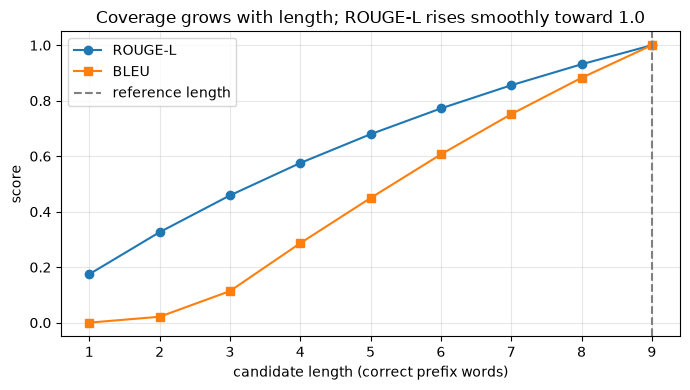

In [16]:
import matplotlib.pyplot as plt

reference = "the quick brown fox jumps over the lazy dog"
full = tokens(reference)
lengths, rl_scores, bleu_scores = [], [], []
try:
    from evals.metrics import bleu
except ImportError:
    bleu = None

for k in range(1, len(full) + 1):
    cand = " ".join(full[:k])          # first k correct words, in order
    lengths.append(k)
    rl_scores.append(rouge_l(cand, reference))
    if bleu:
        bleu_scores.append(bleu(cand, reference))

plt.figure(figsize=(7, 4))
plt.plot(lengths, rl_scores, marker="o", label="ROUGE-L")
if bleu:
    plt.plot(lengths, bleu_scores, marker="s", label="BLEU")
plt.axvline(len(full), ls="--", color="gray", label="reference length")
plt.xlabel("candidate length (correct prefix words)")
plt.ylabel("score")
plt.title("Coverage grows with length; ROUGE-L rises smoothly toward 1.0")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**(b) Paraphrase blindness:** swap in synonyms one at a time. Meaning is preserved; ROUGE-L drops anyway — each substitution breaks the shared subsequence.

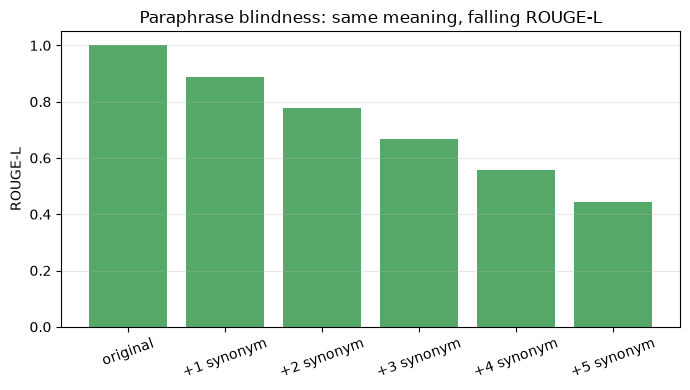

final sentence: the quick tan vixen jumps over the idle dog


In [17]:
reference = "the fast brown fox leaps over the lazy dog"
synonyms = {"fast": "quick", "brown": "tan", "fox": "vixen", "leaps": "jumps", "lazy": "idle"}

cand_words = tokens(reference)
labels, scores = ["original"], [rouge_l(reference, reference)]
swapped = list(cand_words)
for i, (orig, syn) in enumerate(synonyms.items(), 1):
    swapped = [syn if w == orig else w for w in swapped]
    labels.append(f"+{i} synonym")
    scores.append(rouge_l(" ".join(swapped), reference))

plt.figure(figsize=(7, 4))
plt.bar(labels, scores, color="#55A868")
plt.ylabel("ROUGE-L"); plt.xticks(rotation=20)
plt.title("Paraphrase blindness: same meaning, falling ROUGE-L")
plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()
print("final sentence:", " ".join(swapped))

Every swapped sentence means the same thing to a human, yet ROUGE-L decays with each substitution — the same lexical blind spot BLEU has. Using **multiple references** helps ROUGE cover legitimate wording variation, just as it does for BLEU.

## 9. (Optional) Cross-check vs. a reference implementation

If you have Google's `rouge-score` installed, compare. Values won't match *exactly* — that library offers optional stemming and a slightly different F-measure default (`beta = 1`, balanced) — but should be in the same ballpark. This cell is optional and skips cleanly if it isn't installed.

In [18]:
cand = "a cat is sitting on the mat"
ref = "the cat sat on the mat"
print(f"our rouge_l() (beta=1.2): {rouge_l(cand, ref):.4f}")
print(f"our rouge_l() (beta=1.0): {rouge_l(cand, ref, beta=1.0):.4f}\n")

try:
    from rouge_score import rouge_scorer
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)
    score = scorer.score(ref, cand)["rougeL"]   # (reference, candidate)
    print(f"rouge-score rougeL fmeasure (beta=1): {score.fmeasure:.4f}")
    print(f"  precision={score.precision:.4f}  recall={score.recall:.4f}")
except ImportError:
    print("rouge-score not installed  ->  pip install rouge-score   (optional)")

our rouge_l() (beta=1.2): 0.6240
our rouge_l() (beta=1.0): 0.6154

rouge-score not installed  ->  pip install rouge-score   (optional)


## Recap

| Component | Role | In our code |
|---|---|---|
| **Clipped n-gram overlap** | shared n-grams, capped by reference counts | `ngrams` + `min(...)` |
| **Recall** | fraction of the *reference* recovered (ROUGE's core) | `rouge_n_recall` |
| **F-measure (`beta`)** | balance recall vs. precision; `beta=1.2` tilts to recall | `f_measure` |
| **Longest common subsequence** | order-aware overlap without requiring adjacency | `lcs_len` |

$$ \text{ROUGE-L} = F_\beta\!\left(\frac{\text{LCS}}{|\text{cand}|},\ \frac{\text{LCS}}{|\text{ref}|}\right), \quad \beta = 1.2 $$

**Key takeaways**
- ROUGE is **recall-oriented**: it asks how much of the *reference* the candidate covered — the complement to BLEU's precision.
- **ROUGE-L uses LCS**: it rewards correct word *order* without demanding exact *adjacency*, a good fit for summaries.
- It is still **lexical**: synonyms and paraphrase hurt it just like BLEU (section 7). It fails *gracefully* where BLEU fails *cliff-edge*.
- **Report BLEU and ROUGE together**, use **multiple references** when you can, and let an **LLM judge** decide open-ended cases where wording legitimately varies.